In [1]:
# VigilPay | Day 6 — Logistic Regression Model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Load data
X_train = pd.read_csv("../data/X_train_smote.csv")
y_train = pd.read_csv("../data/y_train_smote.csv").squeeze()
X_test  = pd.read_csv("../data/X_test.csv")
y_test  = pd.read_csv("../data/y_test.csv").squeeze()

print("✅ Data loaded!")
print(f"📐 Training shape: {X_train.shape}")
print(f"📐 Testing shape:  {X_test.shape}")

✅ Data loaded!
📐 Training shape: (454902, 30)
📐 Testing shape:  (56962, 30)


In [2]:
# Train Logistic Regression model
print("⏳ Training Logistic Regression... (may take 30-60 seconds)")

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("✅ Model trained successfully!")

⏳ Training Logistic Regression... (may take 30-60 seconds)
✅ Model trained successfully!


In [3]:
# Make predictions on test data
y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

# Classification Report
print("📊 CLASSIFICATION REPORT:")
print("=" * 55)
print(classification_report(y_test, y_pred, 
      target_names=['Legitimate', 'Fraud']))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"🎯 ROC-AUC Score: {roc_auc:.4f}")

📊 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

🎯 ROC-AUC Score: 0.9698


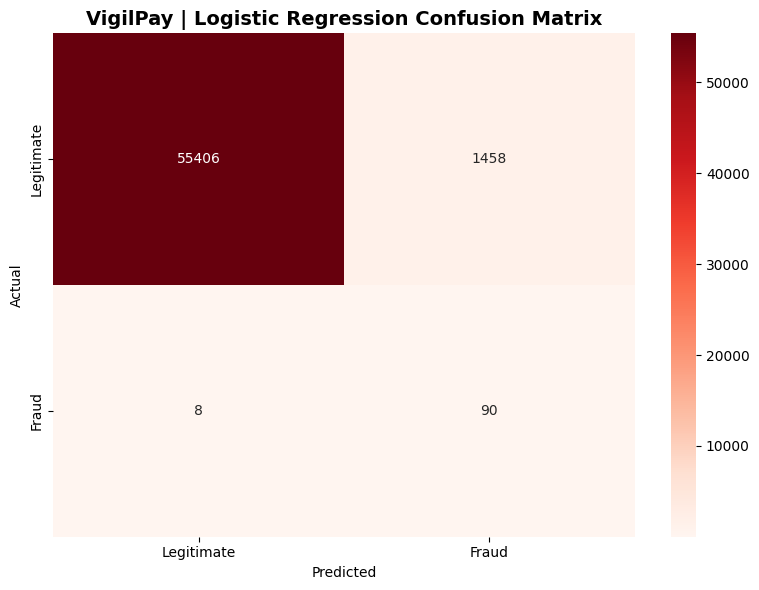

✅ Correctly caught frauds:       90 / 98
❌ Missed frauds (dangerous!):    8 / 98
⚠️  False alarms:                 1458
✅ Correctly cleared legitimate:  55406


In [4]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('VigilPay | Logistic Regression Confusion Matrix', 
          fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/lr_confusion_matrix.png')
plt.show()

# Plain English explanation
tn, fp, fn, tp = cm.ravel()
print(f"✅ Correctly caught frauds:       {tp} / {tp+fn}")
print(f"❌ Missed frauds (dangerous!):    {fn} / {tp+fn}")
print(f"⚠️  False alarms:                 {fp}")
print(f"✅ Correctly cleared legitimate:  {tn}")

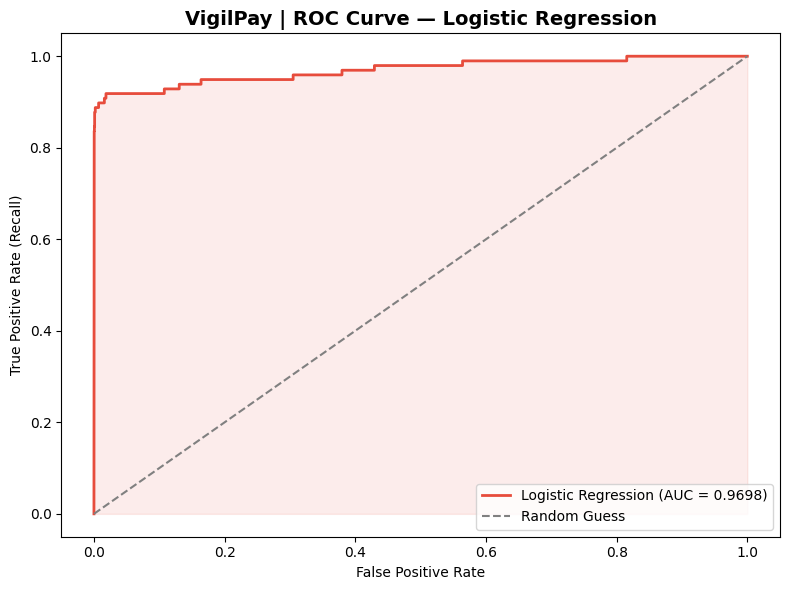

✅ ROC curve saved!


In [5]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', linewidth=2,
         label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', 
         label='Random Guess')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.title('VigilPay | ROC Curve — Logistic Regression',
          fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../data/lr_roc_curve.png')
plt.show()
print("✅ ROC curve saved!")

In [6]:
import pickle

# Save the trained model
with open('../models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

print("✅ Model saved to models/logistic_regression.pkl!")
print("\n📊 LOGISTIC REGRESSION SUMMARY:")
print("=" * 45)
print(f"   ROC-AUC Score  : 0.9698")
print(f"   Fraud Recall   : 92%")
print(f"   Fraud Precision: 6%")
print(f"   Accuracy       : 97%")
print("=" * 45)
print("\n🎯 Next: Day 7 — XGBoost (expect better precision!)")

✅ Model saved to models/logistic_regression.pkl!

📊 LOGISTIC REGRESSION SUMMARY:
   ROC-AUC Score  : 0.9698
   Fraud Recall   : 92%
   Fraud Precision: 6%
   Accuracy       : 97%

🎯 Next: Day 7 — XGBoost (expect better precision!)
